In [21]:
import json, glob, re, pycm, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, scipy.stats as stats
from IPython.display import display, Markdown

In [22]:
EXPERIMENT_RUN_VERSION = "v20-short-form-bil-3-uni-3"
BENCHMARK_SIZE = 448
REPEATED_SAMPLES_PER_EVALUATION = 3

In [23]:
def display_cms(cms):
    fig = plt.figure(figsize=(20,14))
    gs = fig.add_gridspec(4, 5, hspace=0.5)
    axes = gs.subplots()
    for ax, (name, cm) in zip(axes.flat, cms):
        df = pd.DataFrame(cm.matrix).T.fillna(0)
        sns.heatmap(df, annot=True, fmt='d', cmap="YlGnBu", ax=ax)
        ax.set_title(name, wrap=True, fontsize=9)
        ax.set(xlabel='Predicted', ylabel='Actual')
    for ax in axes.flat[len(cms):]:
        ax.set_visible(False)
    plt.show()

In [24]:
def unilateral_truth_value_distribution(df):
    model_evals = df.groupby('model_name')['evaluation'].value_counts().unstack(fill_value=0)
    for stat in ["t","f","n"]:
        if stat not in model_evals:
            model_evals[stat] = 0
    model_evals["t"] = model_evals["t"] / float(BENCHMARK_SIZE)
    model_evals["n"] = model_evals["n"] / float(BENCHMARK_SIZE)
    model_evals["f"] = model_evals["f"] / float(BENCHMARK_SIZE)
    return model_evals[["t", "n", "f"]]

In [25]:
def bilateral_truth_value_distribution(df):
    model_evals = df.groupby('model_name')['evaluation'].value_counts().unstack(fill_value=0)
    for stat in ["t","f","n", "b"]:
        if stat not in model_evals:
            model_evals[stat] = 0
    model_evals["t"] = model_evals["t"] / float(BENCHMARK_SIZE)
    model_evals["b"] = model_evals["b"] / float(BENCHMARK_SIZE)
    model_evals["n"] = model_evals["n"] / float(BENCHMARK_SIZE)
    model_evals["f"] = model_evals["f"] / float(BENCHMARK_SIZE)
    return model_evals[["t", "n", "b",  "f"]]

In [26]:
def plot_f1_comparison(df, n, figsize=(15, 6)):
    # Set the colors
    unilateral_color = '#8884d8'
    bilateral_color = '#82ca9d'

    # Create figure with larger size
    plt.figure(figsize=figsize)

    # Calculate bar positions
    x = np.arange(len(df))
    width = 0.35

    # Create bars
    bars1 = plt.bar(x - width/2, df['unilateral F1 macro'], width, label='Unilateral', color=unilateral_color, alpha=0.8)
    bars2 = plt.bar(x + width/2, df['bilateral F1 macro'], width, label='Bilateral', color=bilateral_color, alpha=0.8)

    # Set y-axis limits
    plt.ylim(0, 1.0)

    # Add value labels on top of bars
    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center', va='bottom')

    autolabel(bars1)
    autolabel(bars2)

    # Customize the plot
    plt.ylabel('F1 macro (given attempted)', fontsize=12)
    plt.title(f'Unilateral vs Bilateral Evaluation (N={int(n):d}, samples/evaluation={REPEATED_SAMPLES_PER_EVALUATION:d})', fontsize=14, pad=20)
    plt.xticks(x, df['model'], rotation=45, ha='right')

    # Adjust layout to prevent label cutoff
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

In [27]:
def plot_acc_comparison(df, n, figsize=(15, 6)):
    # Set the colors
    unilateral_color = '#8884d8'
    bilateral_color = '#82ca9d'

    # Create figure with larger size
    plt.figure(figsize=figsize)

    # Calculate bar positions
    x = np.arange(len(df))
    width = 0.35

    # Create bars
    bars1 = plt.bar(x - width/2, df['unilateral ACC'], width, label='Unilateral', color=unilateral_color, alpha=0.8)
    bars2 = plt.bar(x + width/2, df['bilateral ACC'], width, label='Bilateral', color=bilateral_color, alpha=0.8)

    # Set y-axis limits
    plt.ylim(0.0, 1.0)

    # Add value labels on top of bars
    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center', va='bottom')

    autolabel(bars1)
    autolabel(bars2)

    # Customize the plot
    plt.ylabel('Accuracy (given attempted)', fontsize=12)
    plt.title(f'Unilateral vs Bilateral Evaluation (N={int(n):d}, samples/evaluation={REPEATED_SAMPLES_PER_EVALUATION:d})', fontsize=14, pad=20)
    plt.xticks(x, df['model'], rotation=45, ha='right')

    # Adjust layout to prevent label cutoff
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

In [28]:
def plot_metrics_boxplot(df):
    
    # Create long-format data for the three metrics (ACC, AUC, F1 macro)
    unilateral_data = pd.DataFrame({
        'Metric': ['ACC'] * len(df) + ['AUC'] * len(df) + ['F1 macro'] * len(df),
        'Value': df['unilateral ACC'].tolist() + df['unilateral AUC'].tolist() + df['unilateral F1 macro'].tolist(),
        'Type': ['Unilateral'] * (len(df) * 3)
        })

    bilateral_data = pd.DataFrame({
        'Metric': ['ACC'] * len(df) + ['AUC'] * len(df) + ['F1 macro'] * len(df),
        'Value': df['bilateral ACC'].tolist() + df['bilateral AUC'].tolist() + df['bilateral F1 macro'].tolist(),
        'Type': ['Bilateral'] * (len(df) * 3)
    })

    # Combine the data
    plot_data = pd.concat([unilateral_data, bilateral_data])

    # Create the boxplot
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Metric', y='Value', hue='Type', data=plot_data, palette={'Unilateral': '#8884d8', 'Bilateral': '#82ca9d'})
    plt.title('Comparison of Unilateral vs Bilateral Performance Metrics (given attempted)')
    plt.ylabel('Score')
    plt.ylim(0.0, 1.0)

    plt.show()

In [29]:
def plot_tv_distributions(df):
    # Create shortened model names for better visualization
    # df['short_name'] = df['model_name'].apply(lambda x: x.split('/')[-1].split('-')[0])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set width of bars
    barWidth = 0.2
    positions = np.arange(len(df))

    # Create bars
    plt.bar(positions - barWidth*1.5, df['t'], width=barWidth, color='#2ecc71', label='t')
    plt.bar(positions - barWidth*0.5, df['n'], width=barWidth, color='#3498db', label='n')
    plt.bar(positions + barWidth*0.5, df['b'], width=barWidth, color='#f39c12', label='b')
    plt.bar(positions + barWidth*1.5, df['f'], width=barWidth, color='#e74c3c', label='f')

    # Add labels, title and legend
    # plt.xlabel('model', fontsize=12)
    plt.ylabel('percentage occurence of truth value', fontsize=12)
    plt.title('Distribution of truth values across models', fontsize=14)
    plt.xticks(positions, df.index.tolist(), rotation=45, ha='right')
    plt.legend()

    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Ensure layout is tight
    plt.tight_layout()

    # Add value annotations on top of each bar
    for i, value in enumerate(df['t']):
        plt.text(i - barWidth*1.5, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=8)
    for i, value in enumerate(df['n']):
        plt.text(i - barWidth*0.5, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=8)
    for i, value in enumerate(df['b']):
        plt.text(i + barWidth*0.5, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=8)
    for i, value in enumerate(df['f']):
        plt.text(i + barWidth*1.5, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

    plt.show()

In [30]:
cms = {}
for file in glob.glob(f"experiments/{EXPERIMENT_RUN_VERSION}/unilateral/*.json"):
    model = re.match(r'.*/unilateral/(.*)-short-form-factuality-gpqa.json', file).group(1)
    if model not in cms:
        cms[model] = {}
    df = pd.DataFrame.from_records(json.load(open(file, "r"))[:BENCHMARK_SIZE])
    cms[model]["unilateral"] = pycm.ConfusionMatrix(df["label"].tolist(), df["evaluation"].tolist(), digit=2, classes=[ 't', 'f' ])
for file in glob.glob(f"experiments/{EXPERIMENT_RUN_VERSION}/bilateral/*.json"):
    model = re.match(r'.*/bilateral/(.*)-short-form-factuality-gpqa.json', file).group(1)
    if model not in cms:
        cms[model] = {}
    df = pd.DataFrame.from_records(json.load(open(file, "r"))[:BENCHMARK_SIZE])
    cms[model]["bilateral"] = pycm.ConfusionMatrix(df["label"].tolist(), df["evaluation"].tolist(), digit=2, classes=[ 't', 'f' ])

In [31]:
stats_df = pd.DataFrame([ 
    {
        'model': model,
        'unilateral N': cms[model]["unilateral"].POP['t'], 
        'unilateral ACC': cms[model]["unilateral"].ACC_Macro, 
        'unilateral AUC': cms[model]["unilateral"].AUC['t'], 
        'unilateral F1 macro': cms[model]["unilateral"].F1_Macro,
        'bilateral N': cms[model]["bilateral"].POP['t'], 
        'bilateral ACC': cms[model]["bilateral"].ACC_Macro, 
        'bilateral AUC': cms[model]["bilateral"].AUC['t'], 
        'bilateral F1 macro': cms[model]["bilateral"].F1_Macro,
    } 
    for model in cms if "bilateral" in cms[model]
])
stats_df['delta F1'] = stats_df['bilateral F1 macro'] - stats_df['unilateral F1 macro']
stats_df['delta ACC'] = stats_df['bilateral ACC'] - stats_df['unilateral ACC']
stats_df['unilateral coverage'] = stats_df['unilateral N'].apply(lambda x: x / BENCHMARK_SIZE)
stats_df['bilateral coverage'] = stats_df['bilateral N'].apply(lambda x: x / BENCHMARK_SIZE)
stats_df = stats_df[[ 'model', 
                     'unilateral coverage', 'unilateral ACC', 'unilateral AUC', 'unilateral F1 macro', 
                     'bilateral coverage', 'bilateral ACC', 'bilateral AUC', 'bilateral F1 macro', 
                     'delta ACC', 'delta F1' ]].sort_values('delta ACC', ascending=False)

In [32]:
columns = [
    ('', 'model'),
    ('unilateral', 'coverage'),
    ('unilateral', 'ACC'),
    ('unilateral', 'AUC'),
    ('unilateral', 'F1 macro'),
    ('bilateral', 'coverage'),
    ('bilateral', 'ACC'),
    ('bilateral', 'AUC'),
    ('bilateral', 'F1 macro'),
    ('', 'delta ACC'),
    ('', 'delta F1')
]

original_columns = ['model',
                   'unilateral coverage', 'unilateral ACC', 'unilateral AUC', 'unilateral F1 macro',
                   'bilateral coverage', 'bilateral ACC', 'bilateral AUC', 'bilateral F1 macro',
                   'delta ACC', 'delta F1']

df_new = stats_df[original_columns].copy()
df_new.columns = pd.MultiIndex.from_tuples(columns)
df_new = df_new.reset_index(drop=True)

df_new = df_new.style.format({
    ('', 'model'): '{}',
    ('unilateral', 'coverage'): '{:.3f}',
    ('unilateral', 'ACC'): '{:.3f}',
    ('unilateral', 'AUC'): '{:.3f}',
    ('unilateral', 'F1 macro'): '{:.3f}',
    ('bilateral', 'coverage'): '{:.3f}',
    ('bilateral', 'ACC'): '{:.3f}',
    ('bilateral', 'AUC'): '{:.3f}',
    ('bilateral', 'F1 macro'): '{:.3f}',
    ('', 'delta ACC'): '{:.3f}',
    ('', 'delta F1'): '{:.3f}'
})

In [33]:
# For ACC
uni_acc = stats_df['unilateral ACC']
bi_acc = stats_df['bilateral ACC']
stat_acc, p_acc = stats.mannwhitneyu(uni_acc, bi_acc, alternative='less')

# For AUC
uni_auc = stats_df['unilateral AUC']
bi_auc = stats_df['bilateral AUC']
stat_auc, p_auc = stats.mannwhitneyu(uni_auc, bi_auc, alternative='less')

# For F1 macro
uni_f1 = stats_df['unilateral F1 macro']
bi_f1 = stats_df['bilateral F1 macro']
stat_f1, p_f1 = stats.mannwhitneyu(uni_f1, bi_f1, alternative='less')

In [34]:
flagship_models = [
    "claude-3-5-sonnet-20241022",
    "deepseek-chat-v3-0324",
    "llama-4-maverick",
    "phi-4",
    "nf-gpt-4o",
    "qwen-2.5-72b-instruct",
    "qwq-32b",
    "olmo-2-0325-32b-instruct"
]

distilled_models = [
    "claude-3-5-haiku-20241022",
    "deepseek-r1-distill-llama-8b",
    "gemini-2.0-flash-001",
    "gemma-2-27b-it",
    "llama-4-scout",
    "nf-gpt-4o-mini",
    "o3-mini"
]

flagship_df = stats_df[stats_df['model'].isin(flagship_models)]
distilled_df = stats_df[stats_df['model'].isin(distilled_models)]

flagship_uni_acc = flagship_df['unilateral ACC']
flagship_bi_acc = flagship_df['bilateral ACC']
flagship_stat_acc, flagship_p_acc = stats.mannwhitneyu(flagship_uni_acc, flagship_bi_acc, alternative='less')
flagship_uni_auc = flagship_df['unilateral AUC']
flagship_bi_auc = flagship_df['bilateral AUC']
flagship_stat_auc, flagship_p_auc = stats.mannwhitneyu(flagship_uni_auc, flagship_bi_auc, alternative='less')
flagship_uni_f1 = flagship_df['unilateral F1 macro']
flagship_bi_f1 = flagship_df['bilateral F1 macro']
flagship_stat_f1, flagship_p_f1 = stats.mannwhitneyu(flagship_uni_f1, flagship_bi_f1, alternative='less')

distilled_uni_acc = distilled_df['unilateral ACC']
distilled_bi_acc = distilled_df['bilateral ACC']
distilled_stat_acc, distilled_p_acc = stats.mannwhitneyu(distilled_uni_acc, distilled_bi_acc, alternative='less')
distilled_uni_auc = distilled_df['unilateral AUC']
distilled_bi_auc = distilled_df['bilateral AUC']
distilled_stat_auc, distilled_p_auc = stats.mannwhitneyu(distilled_uni_auc, distilled_bi_auc, alternative='less')
distilled_uni_f1 = distilled_df['unilateral F1 macro']
distilled_bi_f1 = distilled_df['bilateral F1 macro']
distilled_stat_f1, distilled_p_f1 = stats.mannwhitneyu(distilled_uni_f1, distilled_bi_f1, alternative='less')

In [35]:
unilateral_results = []
for file in glob.glob(f"experiments/{EXPERIMENT_RUN_VERSION}/unilateral/*.json"):
   unilateral_results += json.load(open(file, "r"))[:BENCHMARK_SIZE]
df_unilateral = pd.DataFrame(unilateral_results)
df_unilateral_tv_dist = unilateral_truth_value_distribution(df_unilateral)

In [36]:
bilateral_results = []
for file in glob.glob(f"experiments/{EXPERIMENT_RUN_VERSION}/bilateral/*.json"):
   bilateral_results += json.load(open(file, "r"))[:BENCHMARK_SIZE]
df_bilateral = pd.DataFrame(bilateral_results)
df_bilateral["model_name"] = df_bilateral['model_name'].str.split('/').str[-1]
df_flagship_bilateral = df_bilateral[df_bilateral['model_name'].isin(flagship_models)]
df_distilled_bilateral = df_bilateral[df_bilateral['model_name'].isin(distilled_models)]
df_bilateral_tv_dist = bilateral_truth_value_distribution(df_bilateral)
df_flagship_bilateral_tv_dist = bilateral_truth_value_distribution(df_flagship_bilateral)
df_distilled_bilateral_tv_dist = bilateral_truth_value_distribution(df_distilled_bilateral)

In [37]:
df_flagship_bilateral_tv_dist

evaluation,t,n,b,f
model_name,,,,
claude-3-5-sonnet-20241022,0.1875,0.044643,0.024554,0.026786


In [38]:
df_distilled_bilateral_tv_dist

evaluation,t,n,b,f
model_name,,,,
o3-mini,0.037946,0.006696,0.002232,0.006696


# Accuracy (given attempted) by model

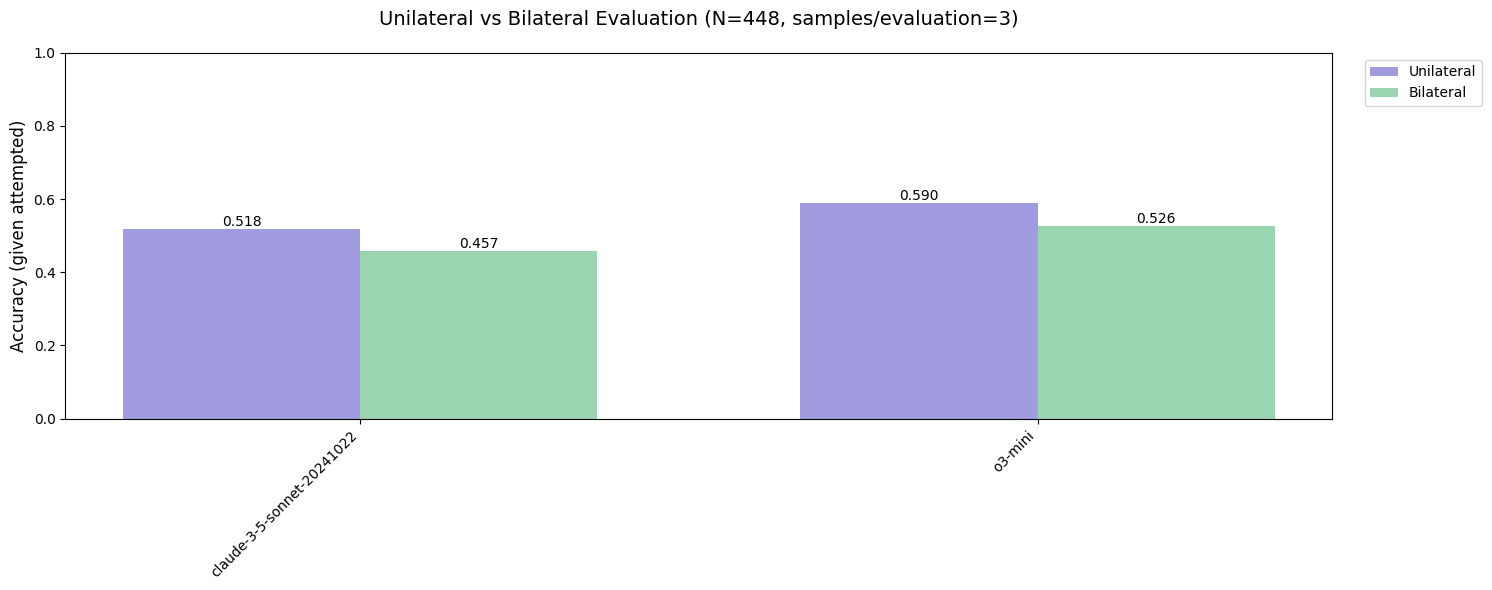

# Metrics boxplot

## All models

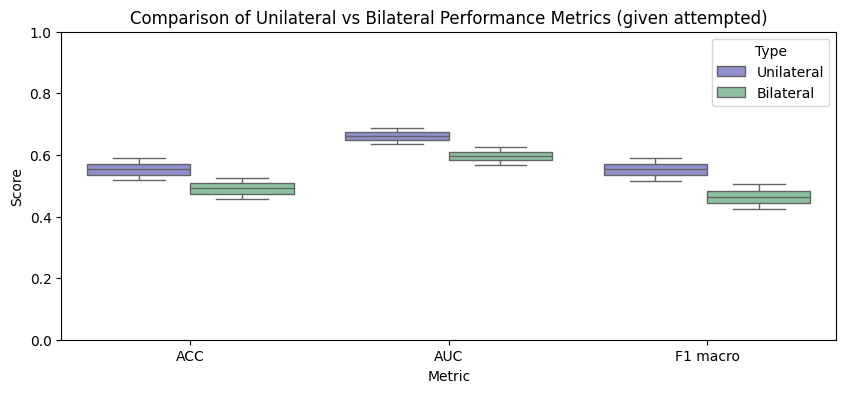

## Flagship models

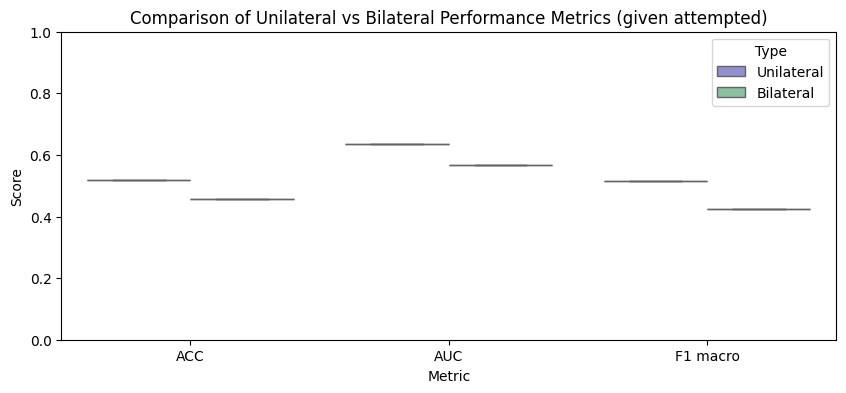

## Distilled models

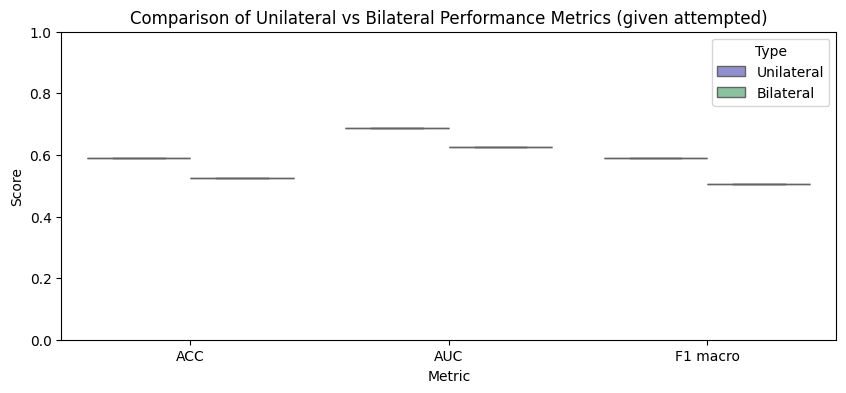

## Mann-Whitney U test

### All models

* ACC: U=3.0, p=0.833

* AUC: U=4.0, p=1.000

* F1 macro: U=4.0, p=1.000

...

## Unilateral

evaluation,t,n,f
model_name,,,
claude-3-5-haiku-20241022,0.765625,0.004464,0.147321
claude-3-5-sonnet-20241022,0.678571,0.000000,0.321429
deepseek/deepseek-r1-distill-llama-8b,0.428571,0.002232,0.040179
o3-mini,0.638393,0.000000,0.361607


## Bilateral

evaluation,t,n,b,f
model_name,,,,
claude-3-5-sonnet-20241022,0.187500,0.044643,0.024554,0.026786
o3-mini,0.037946,0.006696,0.002232,0.006696


### Flagship models

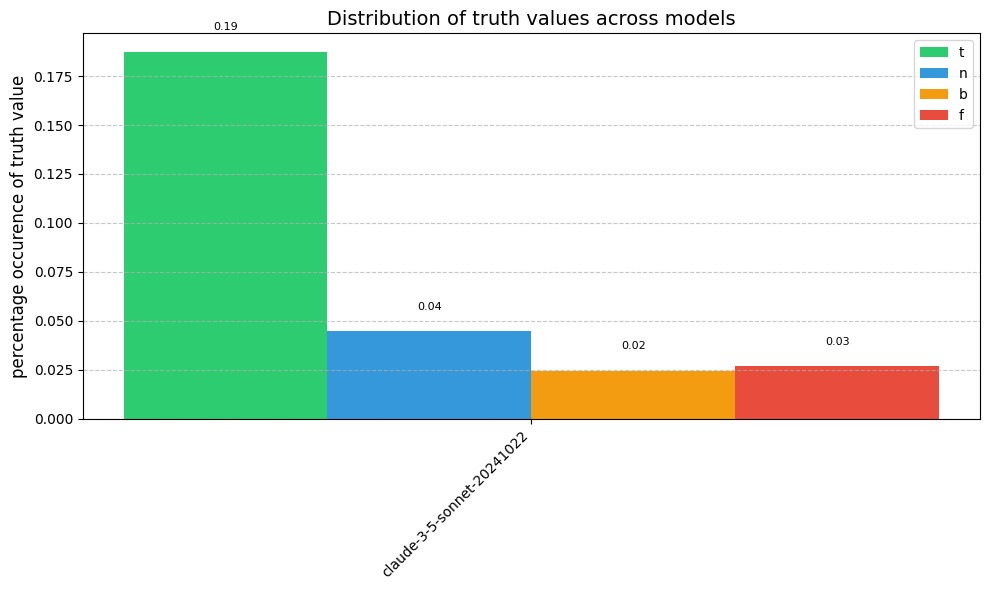

### Distilled models

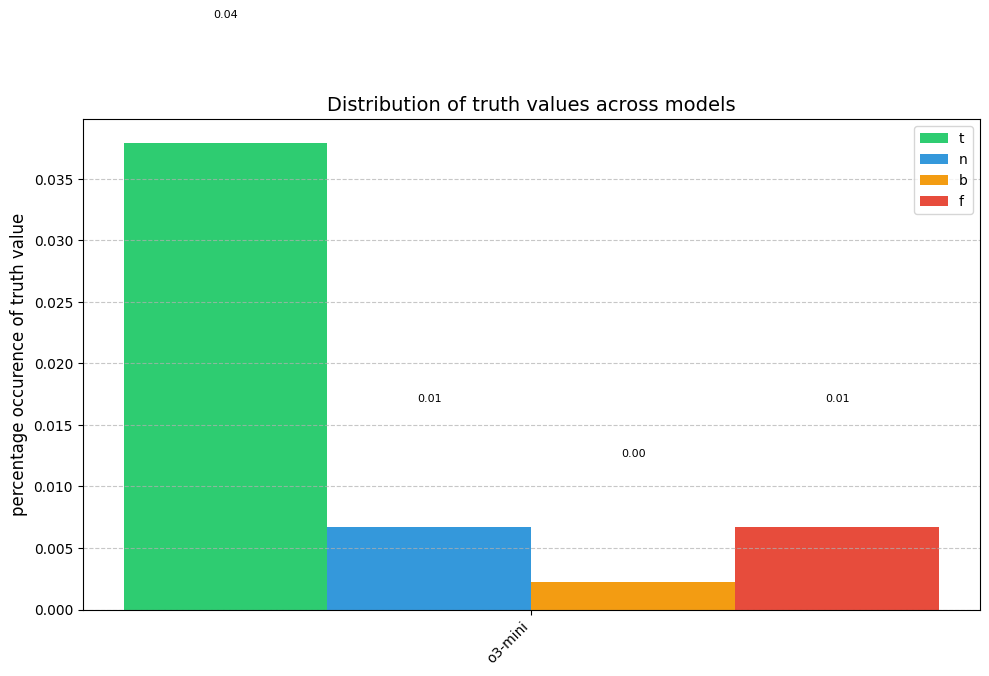

In [39]:
display(Markdown("# Accuracy (given attempted) by model"))
display(df_new)
plot_acc_comparison(stats_df, BENCHMARK_SIZE)
display(Markdown("# Metrics boxplot"))
display(Markdown("## All models"))
plot_metrics_boxplot(stats_df)
display(Markdown("## Flagship models"))
plot_metrics_boxplot(flagship_df)
display(Markdown("## Distilled models"))
plot_metrics_boxplot(distilled_df)
display(Markdown("## Mann-Whitney U test"))
display(Markdown("### All models"))
display(Markdown(f"* ACC: U={stat_acc:.1f}, p={p_acc:.3f}"))
display(Markdown(f"* AUC: U={stat_auc:.1f}, p={p_auc:.3f}"))
display(Markdown(f"* F1 macro: U={stat_f1:.1f}, p={p_f1:.3f}"))
display(Markdown("### Flagship models"))
display(Markdown(f"* ACC: U={flagship_stat_acc:.1f}, p={flagship_p_acc:.3f}"))
display(Markdown(f"* AUC: U={flagship_stat_auc:.1f}, p={flagship_p_auc:.3f}"))
display(Markdown(f"* F1 macro: U={flagship_stat_f1:.1f}, p={flagship_p_f1:.3f}"))
display(Markdown("### Distilled models"))
display(Markdown(f"* ACC: U={distilled_stat_acc:.1f}, p={distilled_p_acc:.3f}"))
display(Markdown(f"* AUC: U={distilled_stat_auc:.1f}, p={distilled_p_auc:.3f}"))
display(Markdown(f"* F1 macro: U={distilled_stat_f1:.1f}, p={distilled_p_f1:.3f}"))
display(Markdown("# Truth value distribution by model"))
display(Markdown(f'## Unilateral'))
display(df_unilateral_tv_dist)
display(Markdown(f'## Bilateral'))
display(df_bilateral_tv_dist)
display(Markdown("### Flagship models"))
plot_tv_distributions(df_flagship_bilateral_tv_dist)
display(Markdown("### Distilled models"))
plot_tv_distributions(df_distilled_bilateral_tv_dist)

# display(Markdown("# Confusion matrices given attempted by model"))
# for model in cms:
#     if "bilateral" in cms[model]:
#         display(Markdown(f'## {model}'))
#         display_cms([(f"unilateral", cms[model]["unilateral"]), (f"bilateral", cms[model]["bilateral"])])

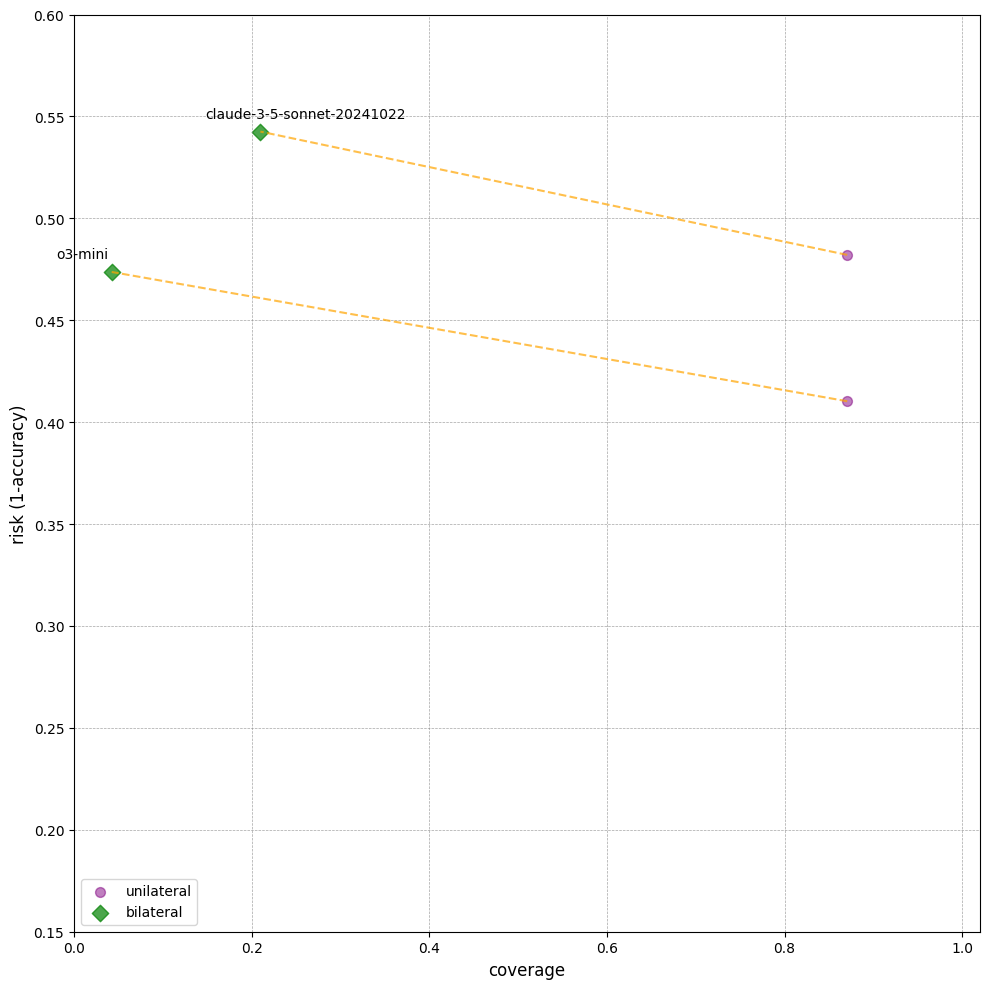

In [40]:
# Calculate risk as 1 - accuracy
stats_df['unilateral risk'] = 1 - stats_df['unilateral ACC']
stats_df['bilateral risk'] = 1 - stats_df['bilateral ACC']

# Create a figure with a specific size
plt.figure(figsize=(10, 10))

# Plot the models
unilateral_points = plt.scatter(stats_df['unilateral coverage'], stats_df['unilateral risk'], 
                               color='purple', alpha=0.5, marker='o', s=50, label='unilateral')
bilateral_points = plt.scatter(stats_df['bilateral coverage'], stats_df['bilateral risk'], 
                              color='green', alpha=0.7, marker='D', s=70, label='bilateral')

# Draw dashed lines connecting the same model in different methods
for i in range(len(stats_df)):
    model = stats_df['model'][i]
    x_coords = [stats_df['unilateral coverage'][i], stats_df['bilateral coverage'][i]]
    y_coords = [stats_df['unilateral risk'][i], stats_df['bilateral risk'][i]]
    plt.plot(x_coords, y_coords, 'orange', linestyle='--', alpha=0.7)
    
    plt.annotate(model, 
        (stats_df['bilateral coverage'][i], stats_df['bilateral risk'][i]),
            xytext=(-40, 10), textcoords='offset points')

# Set labels and title
plt.xlabel('coverage', fontsize=12)
plt.ylabel('risk (1-accuracy)', fontsize=12)

# Set axis limits
plt.xlim(0.0, 1.02)
plt.ylim(0.15, 0.6)

# Add grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Add legend
plt.legend(loc='lower left')

# Show the plot
plt.tight_layout()
plt.savefig('risk_coverage_plot.png', dpi=300)
plt.show()